<a href="https://colab.research.google.com/github/veronicagomariz/IngenieriaVeroG/blob/master/Clase_12ADD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad 1: Análisis de Ventas y Productos
##Contexto
En esta semana de tu pasantía en SynthData, te asignaron la tarea de analizar la información de ventas de un cliente especializado en e-commerce. Silvia, la Project Manager y Data Scientist, te ofreció su apoyo para esta tarea. Esta análisis no solo es importante para entender las ventas pasadas, sino también para proponer mejoras y optimizaciones en las estrategias de comercialización.
##Objetivos

* Cargar y explorar múltiples conjuntos de datos que contengan información sobre las ventas, productos y clientes.
* Limpiar y transformar los datos para garantizar su calidad y utilidad.
* Realizar un análisis descriptivo.

##Ejercicio práctico
1. Cargá los conjuntos de datos que contienen la información sobre las ventas, productos y clientes..
2. Explorá cada DataFrame.
3. Limpiá los datos, eliminando duplicados y manejando valores nulos. Asegurate de que las columnas de fecha estén en el formato adecuado.
4. Ideá una manera de calcular el total gastado por cada cliente.
5. En cada paso, documentá tus hallazgos y las modificaciones que vas aplicando.
6. Realizá un análisis de las ventas por categoría de producto y visualiza los resultados utilizando gráficos de barras.

##Datasets
* [ventas.csv](https://drive.google.com/file/d/1b1HXNoTjJsWIl7Irf69nMWRAUCmm9_Gl/view?usp=drive_link)
* [productos.csv](https://drive.google.com/file/d/1caywZW4rcpARXzLek1IxSAgvHqgIAxD5/view?usp=drive_link)
* [clientes.csv](https://drive.google.com/file/d/1UZolfSTZCWEbS8VGtHMZ0jQ-_wVjbUVi/view?usp=drive_link)

##¿Por qué importa esto en SynthData?
Entender las ventas y el comportamiento de los consumidores proporciona información sobre cómo los cambios en la estrategia pueden influir en el rendimiento de ventas. Este ejercicio te permitirá adquirir competencias valiosas en análisis de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datasets
clientes = pd.read_csv('https://drive.google.com/uc?export=download&id=1omAUeyF82ZMOEX5PRfQ0QnjfgVvFTb-j')
productos = pd.read_csv('https://drive.google.com/uc?export=download&id=15dVqstcgT6Ot4ORcAEA6nJM025RWBUaX')
ventas = pd.read_csv('https://drive.google.com/uc?export=download&id=1r9Wzhx1V7CPKrHoGSwKclEDwGGvFW9kk')

2️⃣ Exploración inicial

📌 Qué buscamos acá:

Ver estructura

Tipos de datos

Valores nulos

Cantidad de registros

In [ ]:
clientes.info()
productos.info()
ventas.info()

clientes.head()
productos.head()
ventas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID_Cliente  108 non-null    int64 
 1   Nombre      108 non-null    object
 2   Edad        108 non-null    int64 
 3   Ciudad      108 non-null    object
 4   Ingresos    108 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Producto      43 non-null     int64  
 1   Nombre_Producto  43 non-null     object 
 2   Categoría        43 non-null     object 
 3   Precio_Unitario  43 non-null     float64
 4   Stock            43 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data col

,ID_Venta,ID_Cliente,ID_Producto,Fecha,Cantidad
0,896,31,29,25/04/2025,5
1,358,97,11,21/07/2024,3
2,521,27,25,08/12/2024,10
3,384,6,5,28/10/2024,8
4,887,39,33,02/04/2025,1


3️⃣ Limpieza de datos

In [ ]:
clientes = clientes.drop_duplicates()
productos = productos.drop_duplicates()
ventas = ventas.drop_duplicates()

#Conversión de fechas
ventas['Fecha'] = pd.to_datetime(
    ventas['Fecha'],
    dayfirst=True,
    errors='coerce'
)

clientes.head()
productos.head()
ventas.head()

,ID_Venta,ID_Cliente,ID_Producto,Fecha,Cantidad
0,896,31,29,2025-04-25,5
1,358,97,11,2024-07-21,3
2,521,27,25,2024-12-08,10
3,384,6,5,2024-10-28,8
4,887,39,33,2025-04-02,1


4️⃣ Calcular total gastado por cliente

In [ ]:
df = ventas.merge(productos, on='ID_Producto')
df = df.merge(clientes, on='ID_Cliente')

df['Total_Venta'] = df['Cantidad'] * df['Precio_Unitario']

gasto_cliente = (
    df.groupby(['ID_Cliente', 'Nombre'])['Total_Venta']
      .sum()
      .reset_index()
      .sort_values('Total_Venta', ascending=False)
)

gasto_cliente.head()

,ID_Cliente,Nombre,Total_Venta
78,79,Lydia Proby,16443.0
95,96,Gaylord MacGibbon,9652.0
14,15,Natasha Velden,9215.0
84,85,Toma Yurasov,8179.5
7,8,Nona Jordine,7295.0


 5️⃣Análisis de ventas por categoría

In [ ]:
ventas_categoria = (
    df.groupby('Categoría')['Total_Venta']
      .sum()
      .sort_values(ascending=False)
)

print(ventas_categoria)

Categoría
Electrodomésticos             83750.0
Computación Personal          45700.0
Televisores                   38640.0
Telefonía y Comunicaciones    36000.0
Fotografía                    34200.0
Video y Fotografía            28990.0
Climatización                 23880.0
Computación de Escritorio     13560.0
Tablets y E-Readers           11685.0
Consolas y Videojuegos        11500.0
Oficina y Hogar                8870.0
Limpieza y Hogar               8100.0
Wearables                      6650.0
Multimedia                     6318.0
Redes y Networking             6105.0
Accesorios de Audio            4650.0
Audio y Sonido                 3424.0
Almacenamiento                 1691.5
Accesorios                      548.0
Seguridad y Vigilancia          360.0
Name: Total_Venta, dtype: float64


6️⃣ Visualización – Gráfico de barras

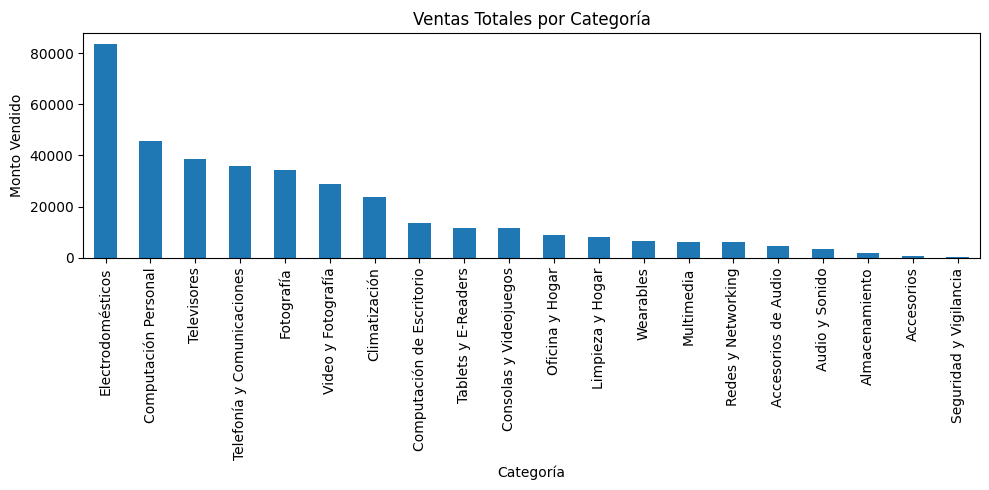

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
ventas_categoria.plot(kind='bar')
plt.title('Ventas Totales por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Monto Vendido')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Actividad 2: Análisis de Asistencia y Resultados en Talleres de Capacitación
## Contexto
Después de realizar un excelente trabajo en la primera actividad, ahora Matías, el Data Analyst en SynthData, te asignó una nueva tarea. Esta vez, vas a analizar la participación y el rendimiento de los asistentes en una serie de talleres de capacitación organizados por una ONG asociada. Tu trabajo es evaluar la efectividad de estos talleres para ayudar a la organización a tomar decisiones para futuras ediciones.
## Objetivos
* Cargar y combinar datos sobre la asistencia a talleres, los participantes y su rendimiento en los talleres.
* Limpiar y transformar los datos, asegurando su integridad y aplicabilidad.
* Realizar un análisis descriptivo para resumir los resultados y la participación en los talleres.
## Ejercicio práctico
1. Cargá los conjuntos de datos.
2. Explorá cada DataFrame para familiarizarte con los datos.
3. Limpiá los datos.
4. Combiná los tres conjuntos de datos en un único DataFrame utilizando las claves apropiadas.
5. Realizá un análisis para calcular la asistencia a los talleres y el puntaje promedio obtenido por los participantes, visualizando los resultados en gráficos.

## Datasets:
* [talleres.csv](https://drive.google.com/file/d/1z42RnewFSBXfygshPS7A4X28dQILC_b0/view?usp=drive_link)
* [participantes.csv](https://drive.google.com/file/d/1IX0bwGw2zJw0RydX0BepGdsUD-O7ivNL/view?usp=drive_link)
* [resultados_taller.csv](https://drive.google.com/file/d/1mEwje4aSOoyxfqdt3tRCpU3RpCTax1wh/view?usp=drive_link)


## ¿Por qué importa esto en SynthData?
Evaluar la asistencia y los resultados de los talleres de capacitación es fundamental para SynthData, ya que les permite realizar mejor sus informes y ayudar a las organizaciones a medir el impacto de sus programas. Esta actividad fortalecerá tu capacidad para trabajar con datos de múltiples fuentes y te preparará para abordar problemas complejos en el ámbito de la ciencia de datos.

1️⃣ Carga de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

talleres = pd.read_csv('https://drive.google.com/uc?export=download&id=1jP-gOXWSHaBoTBuABIqsOIYvlaaXdnhS')
participantes = pd.read_csv('https://drive.google.com/uc?export=download&id=15jJtQl7JgNv-v63V-FOIq1e3hjK-JUSZ')
resultados = pd.read_csv('https://drive.google.com/uc?export=download&id=16nfEXQ5gVIVi3t9lJoTa-w757UzMS-vL')

2️⃣ Exploración inicial

📌 En esta etapa observamos:

Columnas

Tipos de datos

Valores nulos

Cantidad de registros

3️⃣ Limpieza de datos

4️⃣ Combinación de los tres conjuntos

5️⃣ Análisis de asistencia

6️⃣ Puntaje promedio